In [1]:
!pip install numpy
!pip install matplotlib

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
class ContextualBandit():

    def __init__(self):

        self.state = 0

        self.bandits = np.array([
            [0.2, 0, -0.2, -5],
            [0.1, -5, 1, 0.25],
            [-5, 5, 5, 5]
        ])

        self.num_bandits = self.bandits.shape[1]
        self.num_states = self.bandits.shape[0]

    def get_state(self):

        self.state = np.random.randint(0, self.num_states)

        return self.state

    def pull_arm(self, action):

        bandit = self.bandits[self.state, action]

        result = np.random.randn(1)

        if result > bandit:
            return 1
        else:
            return -1

In [4]:
env = ContextualBandit()

print("Number of States:", env.num_states)
print("Number of Bandits:", env.num_bandits)

Number of States: 3
Number of Bandits: 4


In [5]:
state = env.get_state()

print("Current State:", state)

reward = env.pull_arm(2)

print("Reward:", reward)

Current State: 2
Reward: -1


In [6]:
Q = np.zeros([env.num_states, env.num_bandits])

print(Q)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [7]:
num_episodes = 10000

epsilon = 0.1

learning_rate = 0.1

In [8]:
rewards = np.zeros([env.num_states, env.num_bandits])

for episode in range(num_episodes):

    state = env.get_state()

    if np.random.rand(1) < epsilon:

        action = np.random.randint(env.num_bandits)

    else:

        action = np.argmax(Q[state, :])

    reward = env.pull_arm(action)

    Q[state, action] = Q[state, action] + learning_rate * (
        reward - Q[state, action]
    )

    rewards[state, action] += reward

print("Training Complete")

Training Complete


In [9]:

print("Learned Q-Table:")
print(Q)

Learned Q-Table:
[[-0.24633862  0.14677115  0.60154763  1.        ]
 [ 0.00864449  1.         -0.57311213 -0.42444924]
 [ 1.         -0.99982304 -0.99980337 -0.9999383 ]]


In [10]:
for state in range(env.num_states):

    best_action = np.argmax(Q[state])

    print(f"State {state} -> Best Action: {best_action}")

State 0 -> Best Action: 3
State 1 -> Best Action: 1
State 2 -> Best Action: 0


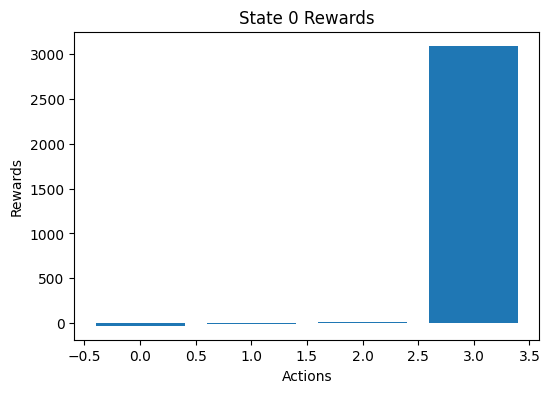

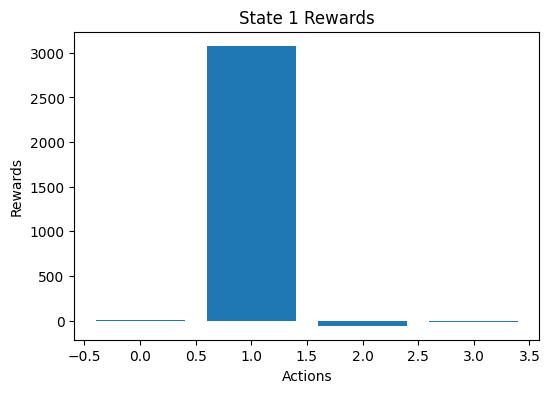

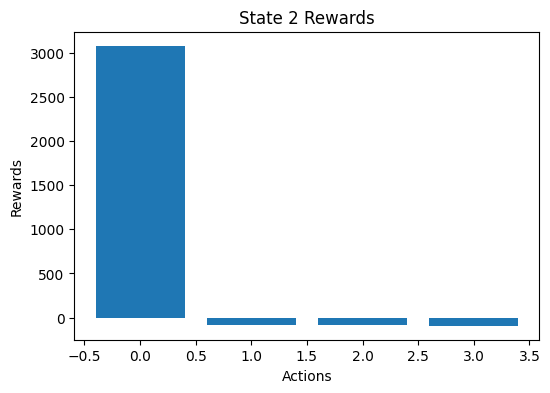

In [11]:
for state in range(env.num_states):

    plt.figure(figsize=(6,4))

    plt.bar(range(env.num_bandits), rewards[state])

    plt.xlabel("Actions")

    plt.ylabel("Rewards")

    plt.title(f"State {state} Rewards")

    plt.show()